In [1]:
# 1. import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

import joblib

In [2]:
#  2. Data Collection & Understanding
# Load dataset

df=pd.read_csv(r"credit_card_fraud.csv.csv")
df

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...
9995,350.91,22,Food,0,0,99,4,37,0
9996,410.04,5,Clothing,0,0,70,3,25,0
9997,527.75,21,Electronics,0,0,44,2,45,0
9998,91.20,2,Electronics,0,0,38,0,37,0


In [3]:
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,Electronics,0,0,66,3,40,0
1,541.82,3,Travel,1,0,87,1,64,0
2,237.01,17,Grocery,0,0,49,1,61,0
3,164.33,4,Grocery,0,1,72,3,34,0
4,30.53,15,Food,0,0,79,0,44,0


In [4]:
# It shows number of rows and columns
df.shape

(10000, 9)

In [5]:
# It shows Column names

df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [6]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   amount               10000 non-null  float64
 1   transaction_hour     10000 non-null  int64  
 2   merchant_category    10000 non-null  str    
 3   foreign_transaction  10000 non-null  int64  
 4   location_mismatch    10000 non-null  int64  
 5   device_trust_score   10000 non-null  int64  
 6   velocity_last_24h    10000 non-null  int64  
 7   cardholder_age       10000 non-null  int64  
 8   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 703.3 KB


In [7]:
# It shows statistical summary

df.describe(include='all')

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Food,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2093,NaN,NaN,NaN,NaN,NaN,NaN
mean,175.949849,11.593300,NaN,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,175.392827,6.922708,NaN,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,0.000000,0.000000,NaN,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,50.905000,6.000000,NaN,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,122.095000,12.000000,NaN,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,242.480000,18.000000,NaN,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000


In [8]:
# Check target distribution
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [9]:
df['is_fraud'].value_counts(normalize=True)*100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

In [10]:
# 3. Data Cleaning & Preprocessing

In [11]:
# Check missing values
df.isnull().sum()

amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [12]:
# Check duplicated rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Remove duplicates if exists 
df.drop_duplicates(inplace=True)

In [14]:
# Keep a copy for EDA before encoding
eda_df = df.copy()


In [15]:
# Check Class Imbalance
# If fraud transactions are much lower than non-fraud:
# (Use class_weight='balanced'
# Or use SMOTE)

df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

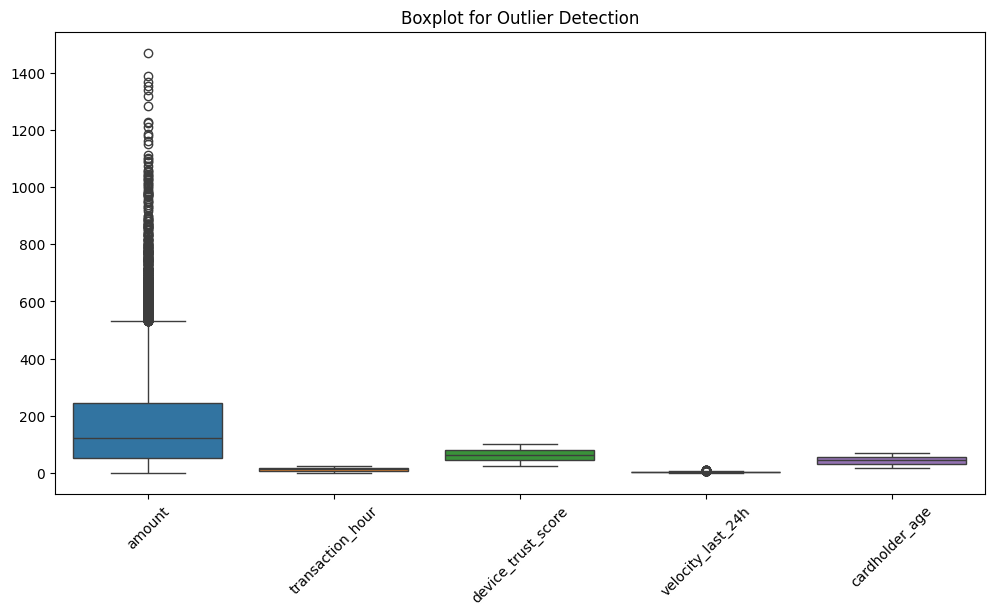

In [16]:
# Check Outliers
# Boxplot for Outlier detection
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['amount','transaction_hour','device_trust_score','velocity_last_24h','cardholder_age']])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [17]:
# Handle Outliers (IQR Method)

def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)

for col in ['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']:
    cap_outliers(df, col)


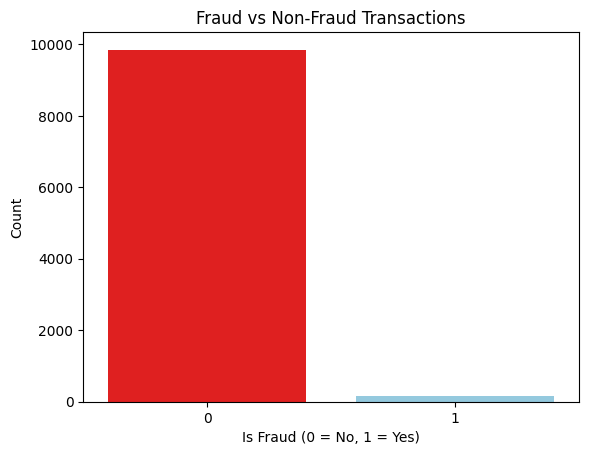

In [18]:
# 4. EDA (Exploratory Data Analysis)
# Basic fraud vs non-fraud analysis
sns.countplot(x='is_fraud', data=eda_df,palette=['red', 'skyblue'])
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

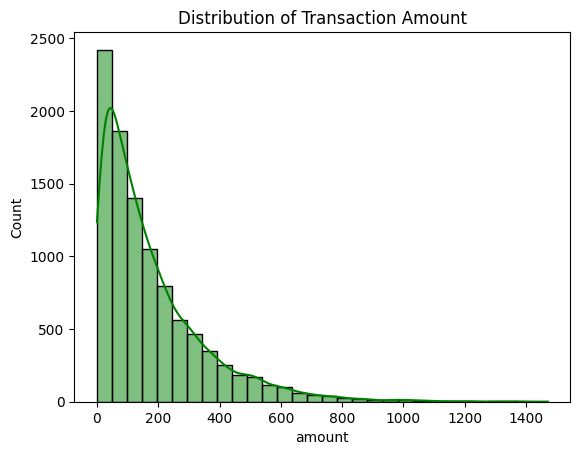

In [19]:
# Univariate Analysis (single feature analysis)
# Distribution of transaction amount
sns.histplot(eda_df['amount'], kde=True, bins=30,color='green')
plt.title("Distribution of Transaction Amount")
plt.show()

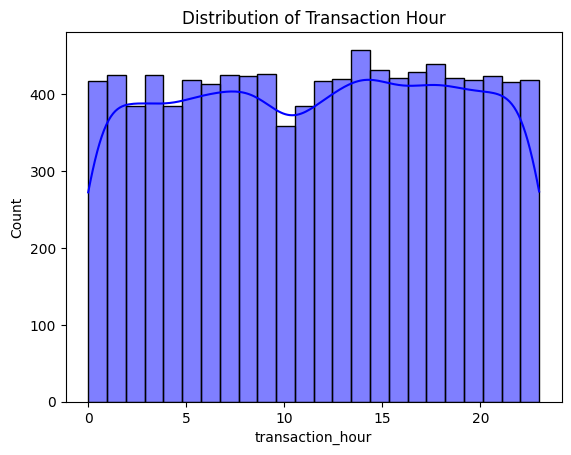

In [20]:
# Distribution of transaction hour
sns.histplot(eda_df['transaction_hour'], kde=True, bins=24,color='Blue')
plt.title("Distribution of Transaction Hour")
plt.show()

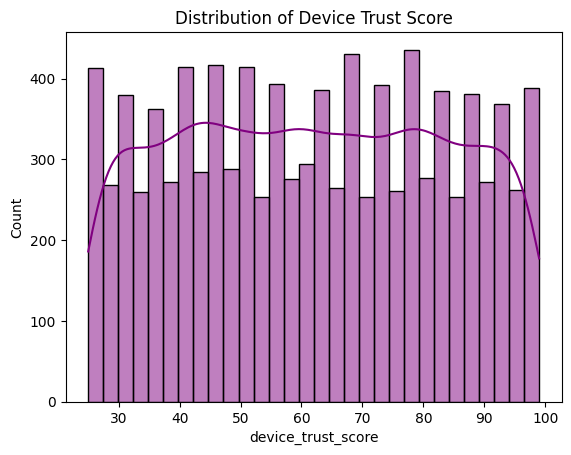

In [21]:
# Distribution of device trust score
sns.histplot(eda_df['device_trust_score'], kde=True, bins=30,color='purple')
plt.title("Distribution of Device Trust Score")
plt.show()

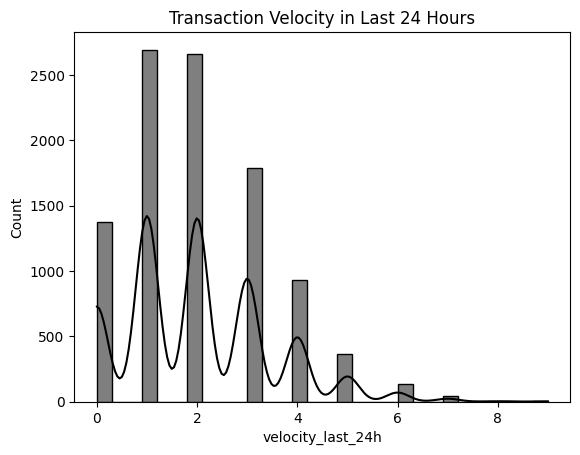

In [22]:
# Distribution of velocity in last 24h
sns.histplot(eda_df['velocity_last_24h'], kde=True, bins=30,color="Black")
plt.title("Transaction Velocity in Last 24 Hours")
plt.show()

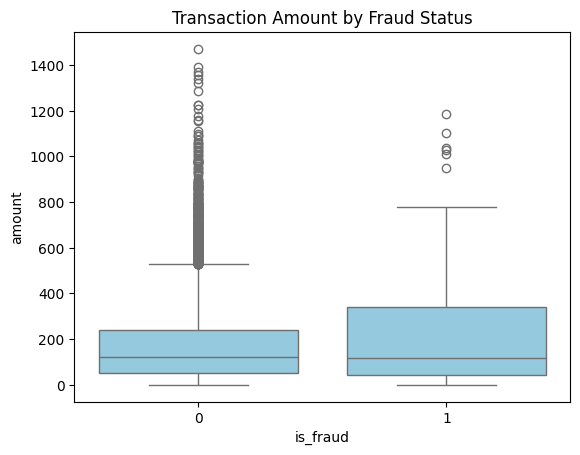

In [23]:
# Fraud vs Non-Fraud comparison by each feature
# Fraud vs Non-Fraud by transaction amount
# Fraud transactions may involve unusually high or suspicious amounts
sns.boxplot(x='is_fraud', y='amount', data=eda_df,color="skyblue")
plt.title("Transaction Amount by Fraud Status")
plt.show()

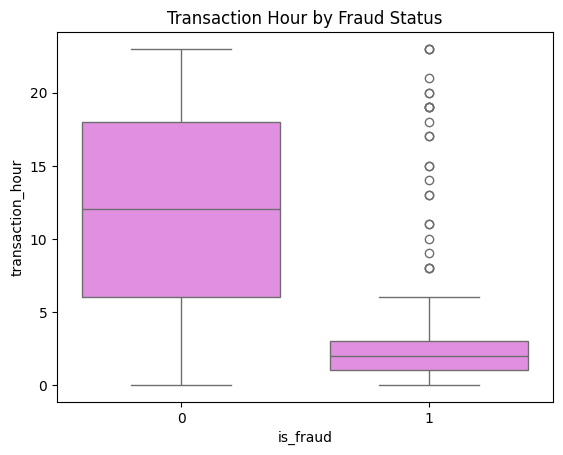

In [24]:
# Fraud vs Non-Fraud by transaction hour
# Fraud may occur more during late night / unusual hours
sns.boxplot(x='is_fraud', y='transaction_hour', data=eda_df,color="violet")
plt.title("Transaction Hour by Fraud Status")
plt.show()

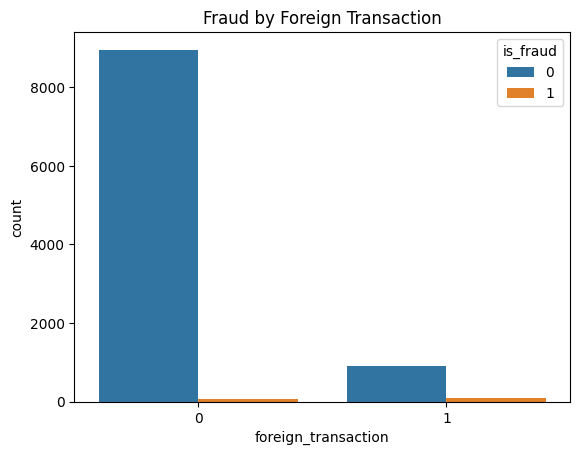

In [25]:
# Fraud vs Non-Fraud by foreign transaction
# Foreign transactions may have higher fraud probability
sns.countplot(x='foreign_transaction', hue='is_fraud', data=eda_df)
plt.title("Fraud by Foreign Transaction")
plt.show()

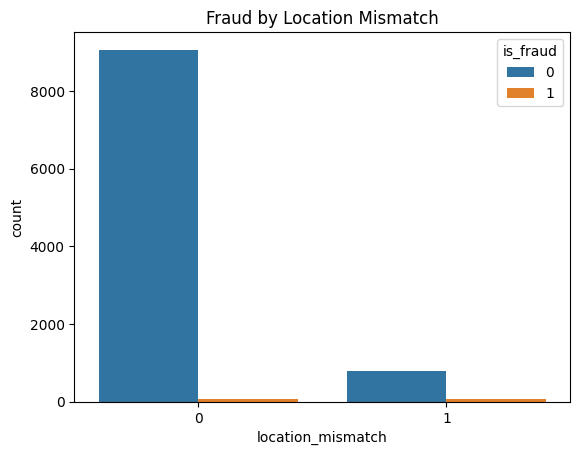

In [26]:
# Fraud vs Non-Fraud by location mismatch
# Location mismatch is usually a strong fraud indicator
sns.countplot(x='location_mismatch', hue='is_fraud', data=eda_df)
plt.title("Fraud by Location Mismatch")
plt.show()

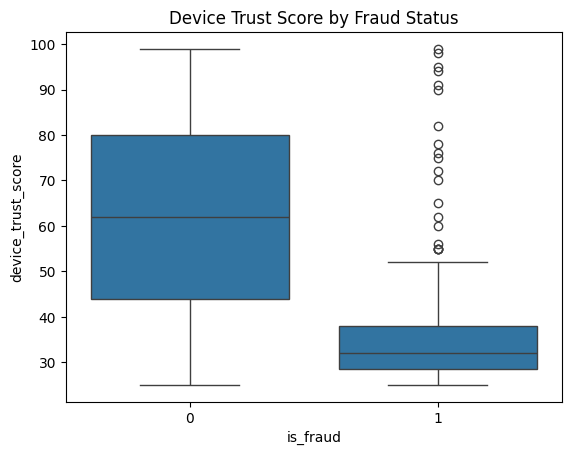

In [27]:
# Fraud vs Non-Fraud by device trust score
# Lower trust score may indicate fraud
sns.boxplot(x='is_fraud', y='device_trust_score', data=eda_df)
plt.title("Device Trust Score by Fraud Status")
plt.show()

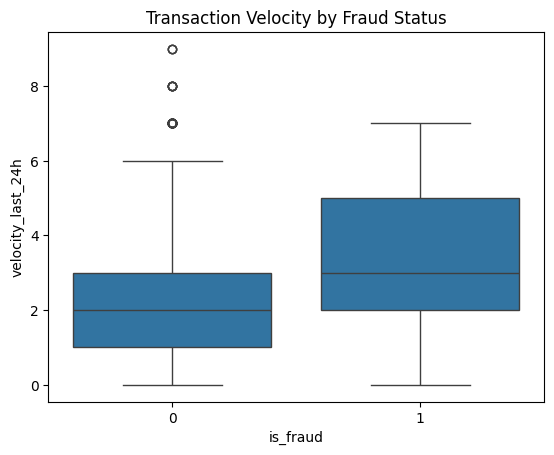

In [28]:
# Fraud vs Non-Fraud by velocity_last_24h
# Multiple rapid transactions may signal fraud
sns.boxplot(x='is_fraud', y='velocity_last_24h', data=eda_df)
plt.title("Transaction Velocity by Fraud Status")
plt.show()

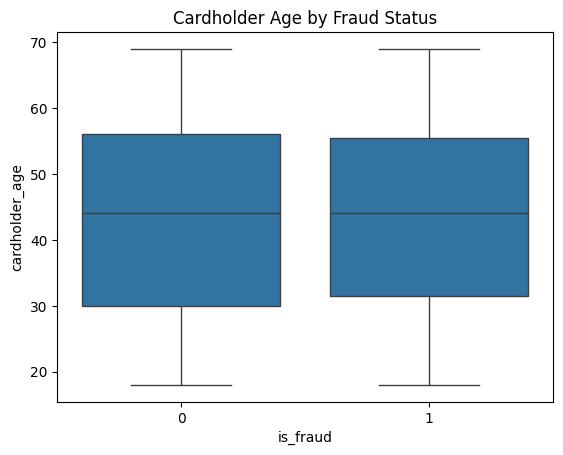

In [29]:
# Fraud vs Non-Fraud by age
sns.boxplot(x='is_fraud', y='cardholder_age', data=eda_df)
plt.title("Cardholder Age by Fraud Status")
plt.show()

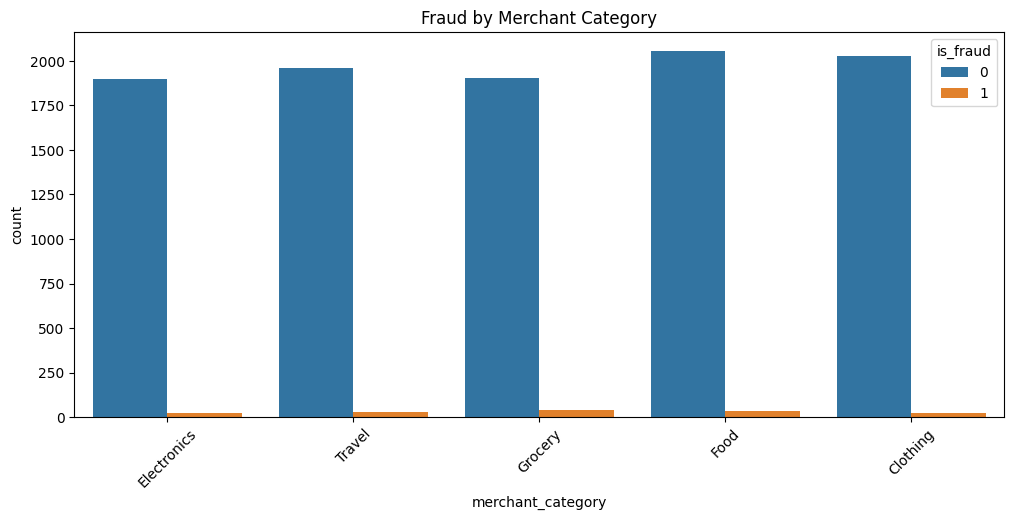

In [55]:
# Fraud by merchant category
# Some merchant categories may be more prone to fraud

plt.figure(figsize=(12,5))
sns.countplot(x='merchant_category', hue='is_fraud', data=eda_df)
plt.xticks(rotation=45)
plt.title("Fraud by Merchant Category")
plt.show()


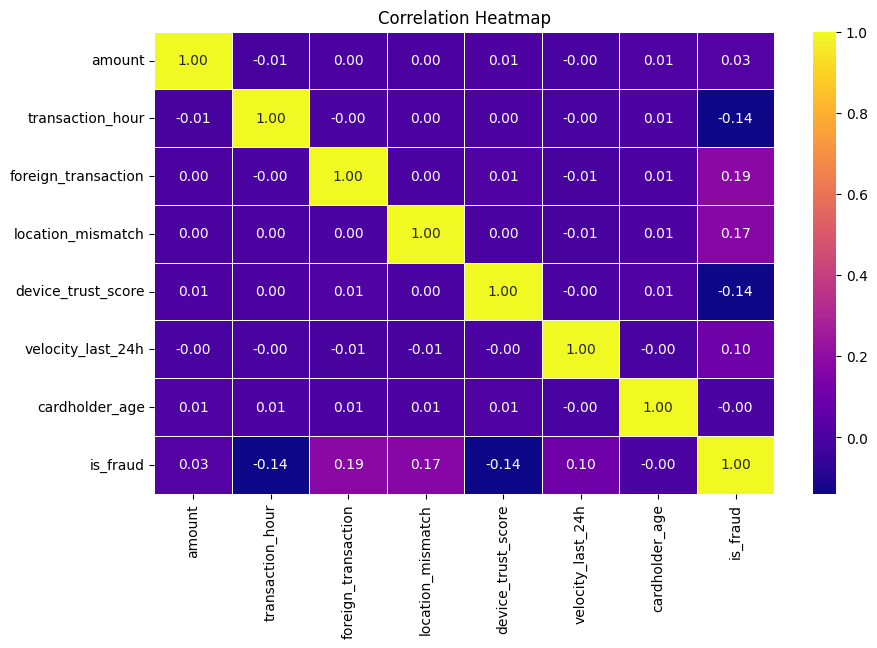

In [56]:
# Correlation Analysis
plt.figure(figsize=(10,6))
numeric_df = eda_df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='plasma', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [57]:
# Grouped statistical analysis
eda_df.groupby('is_fraud')[['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']].mean()

,amount,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,
0,175.333015,62.165804,1.990557,43.469794
1,216.182980,37.867550,3.205298,43.397351


In [58]:
eda_df.groupby('is_fraud')[['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']].median()

,amount,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,
0,122.11,62.0,2.0,44.0
1,118.94,32.0,3.0,44.0


In [34]:
# 5. Final Preprocessing for Model Training
# Define Target and Feature variables
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [35]:
# Encode Categorical Columns
# Using One-Hot Encoding

X = pd.get_dummies(X,columns=['merchant_category'],drop_first=False)

print("Final feature columns:")
print(X.columns.tolist())

Final feature columns:
['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']


In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
# Feature Scaling(only numeric columns)
# Required especially for Logistic Regression

num_cols = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])   # fit only on train
X_test[num_cols] = scaler.transform(X_test[num_cols])         # transform test using train stats

In [39]:
# 6. Model Development
# Logistic Regression

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [40]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
#  7. Model Evaluation
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)


In [42]:
# Metrics
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n{model_name} Evaluation")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")



Logistic Regression Evaluation
Accuracy : 0.9575
Precision: 0.2608695652173913
Recall   : 1.0
F1-score : 0.41379310344827586

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.70      2000
weighted avg       0.99      0.96      0.97      2000


Random Forest Evaluation
Accuracy : 0.993
Precision: 1.0
Recall   : 0.5333333333333333
F1-score : 0.6956521739130435

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.53      0.70        30

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000



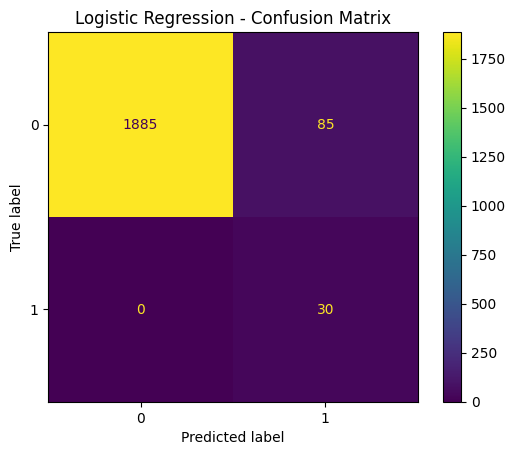

In [43]:
# Confusion Matrix

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

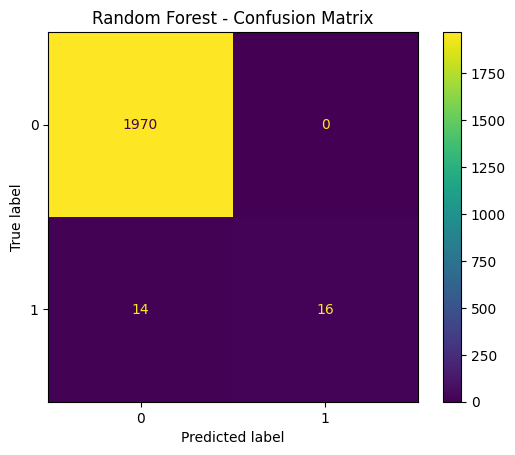

In [44]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [45]:
# ROC-AUC Score
# ROC = Receiver Operating Characteristic
# AUC = Area Under the Curve

y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Logistic Regression ROC-AUC: 0.9933333333333333
Random Forest ROC-AUC: 1.0


In [46]:
# Model Optimization
# Hyperparameter tuning (Random Forest)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


                          Feature  Importance
1                transaction_hour    0.260777
4              device_trust_score    0.256282
2             foreign_transaction    0.136777
5               velocity_last_24h    0.132358
3               location_mismatch    0.107765
0                          amount    0.049899
6                  cardholder_age    0.030046
11       merchant_category_Travel    0.005828
8   merchant_category_Electronics    0.005595
10      merchant_category_Grocery    0.005555
7      merchant_category_Clothing    0.005078
9          merchant_category_Food    0.004041


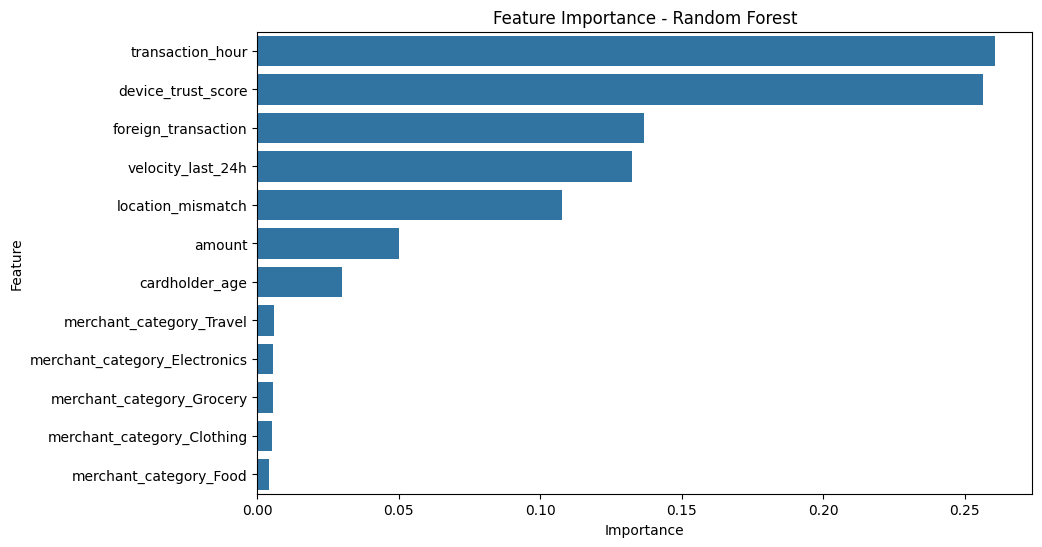

In [47]:
# Feature Importance
# Random Forest can show which features matter most.

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

In [48]:
# Create blank row with all training columns = 0
new_transaction_final = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Fill numeric/basic columns
new_transaction_final['amount'] = 750.50
new_transaction_final['transaction_hour'] = 2
new_transaction_final['foreign_transaction'] = 1
new_transaction_final['location_mismatch'] = 1
new_transaction_final['device_trust_score'] = 20
new_transaction_final['velocity_last_24h'] = 8
new_transaction_final['cardholder_age'] = 45


In [49]:
# Set one merchant category safely
merchant_col = 'merchant_category_Electronics'
if merchant_col in new_transaction_final.columns:
    new_transaction_final[merchant_col] = 1

In [50]:
# Scale only numeric columns
new_transaction_scaled = new_transaction_final.copy()
new_transaction_scaled[num_cols] = scaler.transform(new_transaction_scaled[num_cols])


In [51]:
# Scaling and Predicting
# Logistic Regression

pred_lr = lr.predict(new_transaction_scaled)[0]
prob_lr = lr.predict_proba(new_transaction_scaled)[0][1]

print("Logistic Regression Prediction:", "Fraud" if pred_lr == 1 else "Non-Fraud")
print("Fraud Probability:", round(prob_lr * 100, 8), "%")

Logistic Regression Prediction: Fraud
Fraud Probability: 100.0 %


In [52]:
# Random Forest Classifier

pred_rf = rf.predict(new_transaction_scaled)[0]
prob_rf = rf.predict_proba(new_transaction_scaled)[0][1]
    

print("Random Forest Prediction:", "Fraud" if pred_rf == 1 else "Non-Fraud")
print("Fraud Probability:", round(prob_rf * 100, 8), "%")

Random Forest Prediction: Fraud
Fraud Probability: 69.5 %


In [53]:
# SAVE MODELS FOR FUTURE USE

# If you want to reuse the model later without retraining:

joblib.dump(rf, "random_forest_fraud_model.pkl")
joblib.dump(lr, "logistic_fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Models and scaler and features saved successfully.")

Models and scaler and features saved successfully.


In [54]:
#  LOAD SAVED MODELS

rf_model = joblib.load("random_forest_fraud_model.pkl")
lr_model = joblib.load("logistic_fraud_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

print("Saved models loaded successfully.")
print("Feature columns:", feature_columns)

Saved models loaded successfully.
Feature columns: ['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']
